# SOXL / SOXS Linear Relationship Analysis

SOXL (Direxion Daily Semiconductor Bull 3X) and SOXS (Direxion Daily Semiconductor Bear 3X) are inverse-leveraged pairs tracking the PHLX Semiconductor Index (SOX).

**Goals:**
1. Visualize long-run price dynamics of the pair
2. OLS regression on daily log-returns — measure beta, R², residual noise
3. Rolling beta to detect structural drift (leveraged-ETF decay)
4. Spread / ratio analysis
5. Summary of findings

In [9]:
import sys, pathlib, builtins

# Bootstrap: find project root (contains pyproject.toml) before importing strategy.*
_nb = builtins.__dict__.get('__vsc_ipynb_file__')
_candidates = list(pathlib.Path(_nb).parents) if _nb else []
_candidates += [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents)
_root = next((p for p in _candidates if (p / 'pyproject.toml').exists()), None)
if _root is None:
    raise RuntimeError(f'Cannot find project root. CWD={pathlib.Path.cwd()}')
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import strategy.nb_setup  # noqa: F401 — applies dark theme

## 1. Fetch Data

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from feeds.fetcher import fetch_klines

# ── date range ──────────────────────────────────────────────────────────────
# SOXS IPO: 2010-03-11; use 2018-01-01 for a clean 6-year window
START = "2018-01-01"
END   = "2026-06-11"

df_l = fetch_klines("US.SOXL", "1d", START, END)
df_s = fetch_klines("US.SOXS", "1d", START, END)

print(f"SOXL rows: {len(df_l)}  |  SOXS rows: {len(df_s)}")

[fetcher] Cache hit: US.SOXL 1d  (2122 bars)
[fetcher] Cache hit: US.SOXS 1d  (2122 bars)
SOXL rows: 2122  |  SOXS rows: 2122


In [11]:
# Align on trading date; keep only mutual dates
df_l["date"] = pd.to_datetime(df_l["time_key"]).dt.date
df_s["date"] = pd.to_datetime(df_s["time_key"]).dt.date

df = pd.merge(
    df_l[["date", "open", "high", "low", "close", "volume"]].rename(
        columns={"open": "l_open", "high": "l_high", "low": "l_low",
                 "close": "l_close", "volume": "l_vol"}),
    df_s[["date", "open", "high", "low", "close", "volume"]].rename(
        columns={"open": "s_open", "high": "s_high", "low": "s_low",
                 "close": "s_close", "volume": "s_vol"}),
    on="date",
).sort_values("date").reset_index(drop=True)

print(f"Aligned bars: {len(df)}  ({df['date'].iloc[0]} → {df['date'].iloc[-1]})")
df.tail(3)

Aligned bars: 2122  (2018-01-02 → 2026-06-11)


,date,l_open,l_high,l_low,l_close,l_vol,s_open,s_high,s_low,s_close,s_vol
2119,2026-06-09,227.055,231.02,157.5610,201.68,124754262,5.25,7.11,5.14,5.93,1388857313
2120,2026-06-10,191.540,212.99,177.3001,180.65,94924150,6.24,6.65,5.60,6.57,1208896315
2121,2026-06-11,192.300,225.63,192.3000,223.99,72493397,6.10,6.10,4.90,4.97,910107999


## 2. Price History — Dual Axis

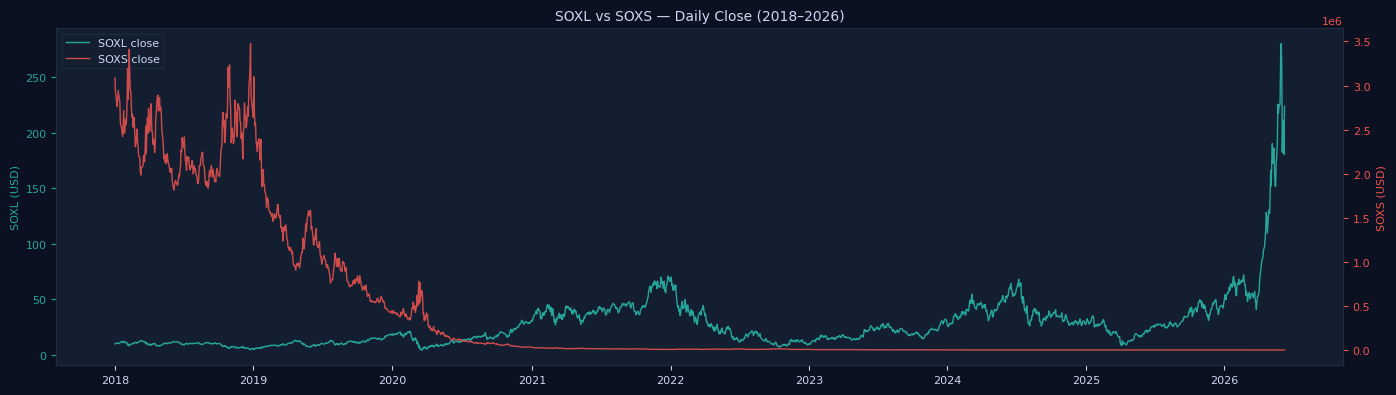

In [12]:
from strategy.nb_setup import BG, BG2, FG, GRID, GREEN, RED, GOLD, BLUE, PURPLE, CYAN, style_ax

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

xs = range(len(df))
ax1.plot(xs, df["l_close"], color=GREEN,  lw=1.0, label="SOXL close")
ax2.plot(xs, df["s_close"], color=RED,    lw=1.0, label="SOXS close", alpha=0.85)

# x-ticks: one label per year
year_idx = df.groupby(df["date"].apply(lambda d: d.year)).apply(lambda g: g.index[0])
ax1.set_xticks(list(year_idx))
ax1.set_xticklabels([str(y) for y in year_idx.index], color=FG, fontsize=8)

ax1.set_ylabel("SOXL (USD)", color=GREEN)
ax2.set_ylabel("SOXS (USD)", color=RED)
ax1.tick_params(axis='y', colors=GREEN)
ax2.tick_params(axis='y', colors=RED)
for sp in ax1.spines.values(): sp.set_edgecolor(GRID)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left", fontsize=8,
           facecolor=BG2, edgecolor=GRID, labelcolor=FG)

ax1.set_facecolor(BG2)
fig.patch.set_facecolor(BG)
ax1.set_title("SOXL vs SOXS — Daily Close (2018–2026)", color=FG, fontsize=10)
plt.tight_layout()
plt.show()

## 3. Log-Return OLS Regression

Because SOXL and SOXS use **3× leverage**, their raw prices diverge strongly over time due to volatility decay.  
The cleanest way to measure the linear relationship is on **daily log-returns**: if SOXL tracks +3× SOX and SOXS tracks −3× SOX, then:

> `r_SOXS ≈ −1 · r_SOXL`  (beta ≈ −1 in return space)

Any deviation from −1 reflects rebalancing friction, tracking error, and decay asymmetry.

OLS  r_SOXS = -0.004783  +  -1.0109 · r_SOXL
R²   = 0.9604   |  p-value = 0.00e+00   |  SE(beta) = 0.0045
Pearson ρ = -0.9800


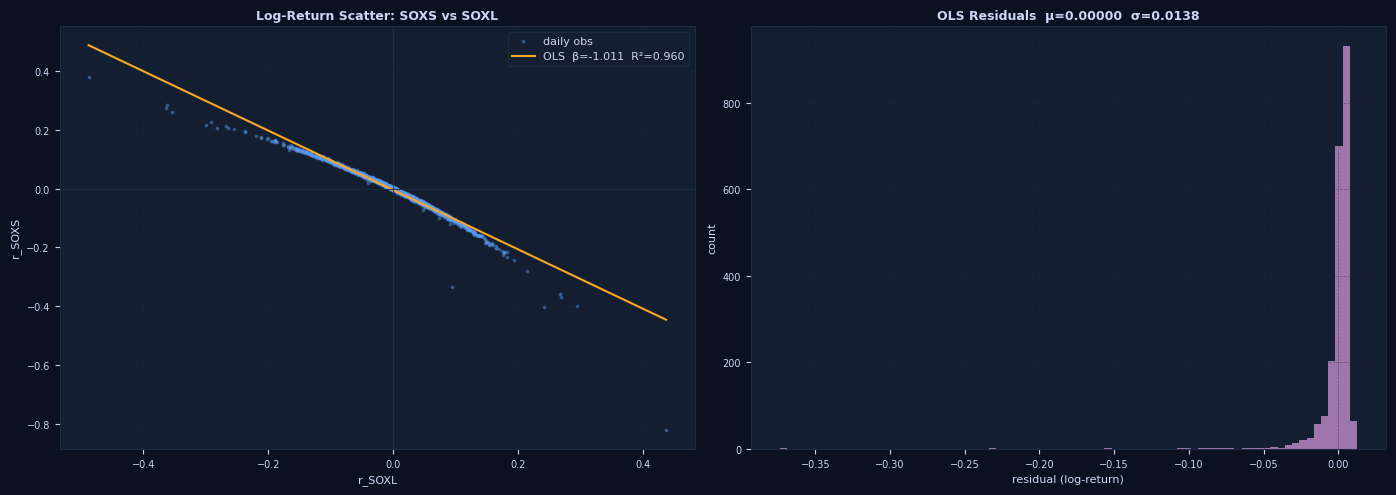

In [13]:
# Daily log-returns
df["r_l"] = np.log(df["l_close"] / df["l_close"].shift(1))
df["r_s"] = np.log(df["s_close"] / df["s_close"].shift(1))
ret = df[["date", "r_l", "r_s"]].dropna().reset_index(drop=True)

# OLS: r_s = alpha + beta * r_l
slope, intercept, r_val, p_val, se = stats.linregress(ret["r_l"], ret["r_s"])
r2 = r_val ** 2

print(f"OLS  r_SOXS = {intercept:+.6f}  +  {slope:.4f} · r_SOXL")
print(f"R²   = {r2:.4f}   |  p-value = {p_val:.2e}   |  SE(beta) = {se:.4f}")
print(f"Pearson ρ = {r_val:.4f}")

# ── scatter + regression line ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.set_facecolor(BG2)
ax.scatter(ret["r_l"], ret["r_s"], s=3, alpha=0.35, color=BLUE, label="daily obs")
xl = np.array([ret["r_l"].min(), ret["r_l"].max()])
ax.plot(xl, intercept + slope * xl, color=GOLD, lw=1.5,
        label=f"OLS  β={slope:.3f}  R²={r2:.3f}")
ax.axhline(0, color=GRID, lw=0.6)
ax.axvline(0, color=GRID, lw=0.6)
style_ax(ax, "Log-Return Scatter: SOXS vs SOXL")
ax.set_xlabel("r_SOXL")
ax.set_ylabel("r_SOXS")
ax.legend(fontsize=8, facecolor=BG2, edgecolor=GRID, labelcolor=FG)

# residual distribution
resid = ret["r_s"] - (intercept + slope * ret["r_l"])
ax2 = axes[1]
ax2.set_facecolor(BG2)
ax2.hist(resid, bins=80, color=PURPLE, alpha=0.75, edgecolor='none')
mu_r, std_r = resid.mean(), resid.std()
style_ax(ax2, f"OLS Residuals  μ={mu_r:.5f}  σ={std_r:.4f}")
ax2.set_xlabel("residual (log-return)")
ax2.set_ylabel("count")

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

## 4. Rolling Beta (60-day window)

A stable −1 beta would mean the pair is perfectly anti-correlated regardless of market regime.  
Drift in the rolling beta reveals periods where leveraged-ETF rebalancing or tracking error breaks the symmetry.

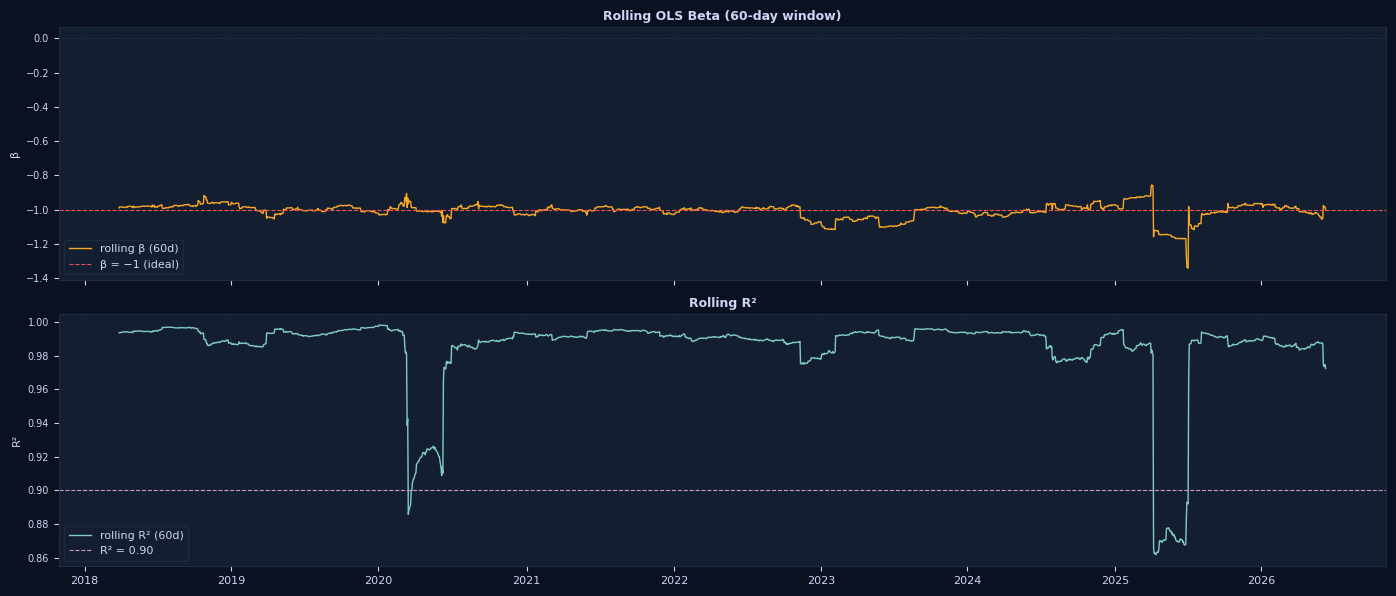

In [14]:
WINDOW = 60  # trading days

def rolling_ols(x: pd.Series, y: pd.Series, w: int):
    """Return Series of rolling OLS slope and R² over window w."""
    betas, r2s = [], []
    for i in range(len(x)):
        if i < w - 1:
            betas.append(np.nan)
            r2s.append(np.nan)
        else:
            xi = x.iloc[i - w + 1: i + 1].values
            yi = y.iloc[i - w + 1: i + 1].values
            s, intercept_, rv, _, _ = stats.linregress(xi, yi)
            betas.append(s)
            r2s.append(rv ** 2)
    return pd.Series(betas, index=x.index), pd.Series(r2s, index=x.index)

roll_beta, roll_r2 = rolling_ols(ret["r_l"], ret["r_s"], WINDOW)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
xs = range(len(ret))

# beta
ax = axes[0]
ax.set_facecolor(BG2)
ax.plot(xs, roll_beta, color=GOLD, lw=1.0, label=f"rolling β ({WINDOW}d)")
ax.axhline(-1.0, color=RED,  lw=0.8, ls="--", label="β = −1 (ideal)")
ax.axhline(0.0,  color=GRID, lw=0.5)
style_ax(ax, f"Rolling OLS Beta ({WINDOW}-day window)")
ax.set_ylabel("β")
ax.legend(fontsize=8, facecolor=BG2, edgecolor=GRID, labelcolor=FG)

# R²
ax2 = axes[1]
ax2.set_facecolor(BG2)
ax2.plot(xs, roll_r2, color=CYAN, lw=1.0, label=f"rolling R² ({WINDOW}d)")
ax2.axhline(0.9, color=PURPLE, lw=0.8, ls="--", label="R² = 0.90")
style_ax(ax2, "Rolling R²")
ax2.set_ylabel("R²")
ax2.legend(fontsize=8, facecolor=BG2, edgecolor=GRID, labelcolor=FG)

# shared x-ticks by year
year_pos = [ret[ret["date"].apply(lambda d: d.year) == y].index[0]
            for y in sorted(ret["date"].apply(lambda d: d.year).unique())]
year_lbl = sorted(ret["date"].apply(lambda d: d.year).unique())
ax2.set_xticks(year_pos)
ax2.set_xticklabels([str(y) for y in year_lbl], fontsize=8)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

## 5. Price Ratio & Log-Price Spread

Because both ETFs track the **same underlying** but in opposite directions, their **log-price sum** (or the ratio SOXL/SOXS) reflects the compounding asymmetry over time.  

- If decay were perfectly symmetric, `log(SOXL) + log(SOXS)` would be constant.  
- An upward trend in the sum means SOXL's long-run bull trend dominates (bull ETFs benefit from uptrending markets).  
- An increasing SOXL/SOXS ratio means SOXL has compounded faster — as expected given the semiconductor sector bull run.

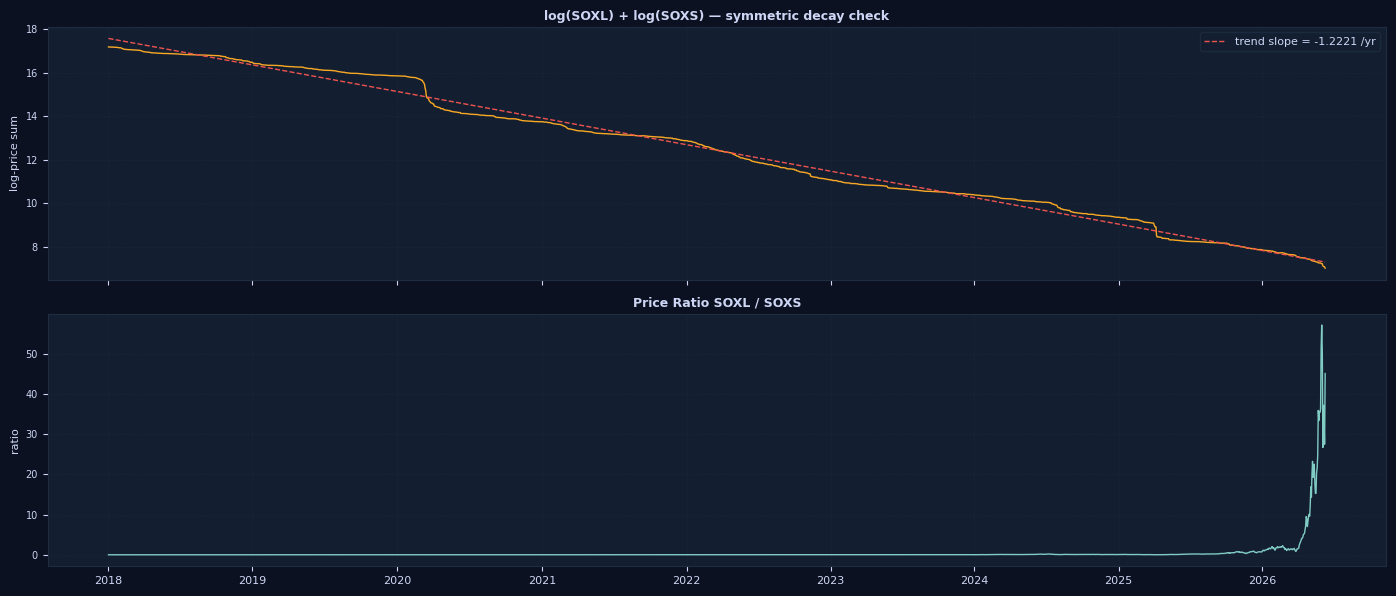

log-sum trend: -1.2221 nats/year  (≈ +-122.21% drift in log-price sum per year)


In [15]:
df["log_l"]   = np.log(df["l_close"])
df["log_s"]   = np.log(df["s_close"])
df["log_sum"] = df["log_l"] + df["log_s"]       # should be ~constant if symmetric decay
df["ratio"]   = df["l_close"] / df["s_close"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
xs = range(len(df))

ax = axes[0]
ax.set_facecolor(BG2)
ax.plot(xs, df["log_sum"], color=GOLD, lw=1.0)
# linear trend overlay
m, b = np.polyfit(xs, df["log_sum"], 1)
ax.plot(xs, [m * x + b for x in xs], color=RED, lw=1.0, ls="--",
        label=f"trend slope = {m*252:.4f} /yr")
style_ax(ax, "log(SOXL) + log(SOXS) — symmetric decay check")
ax.set_ylabel("log-price sum")
ax.legend(fontsize=8, facecolor=BG2, edgecolor=GRID, labelcolor=FG)

ax2 = axes[1]
ax2.set_facecolor(BG2)
ax2.plot(xs, df["ratio"], color=CYAN, lw=1.0)
style_ax(ax2, "Price Ratio SOXL / SOXS")
ax2.set_ylabel("ratio")

# x-ticks
year_idx2 = df.groupby(df["date"].apply(lambda d: d.year)).apply(lambda g: g.index[0])
ax2.set_xticks(list(year_idx2))
ax2.set_xticklabels([str(y) for y in year_idx2.index], fontsize=8)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

print(f"log-sum trend: {m*252:+.4f} nats/year  "
      f"(≈ +{m*252*100:.2f}% drift in log-price sum per year)")

## 6. Return Asymmetry — Bull vs Bear Days

On strongly up days (SOXL +5%), does SOXS drop exactly −5%?  
We split returns by regime and look at the conditional mean ratio.

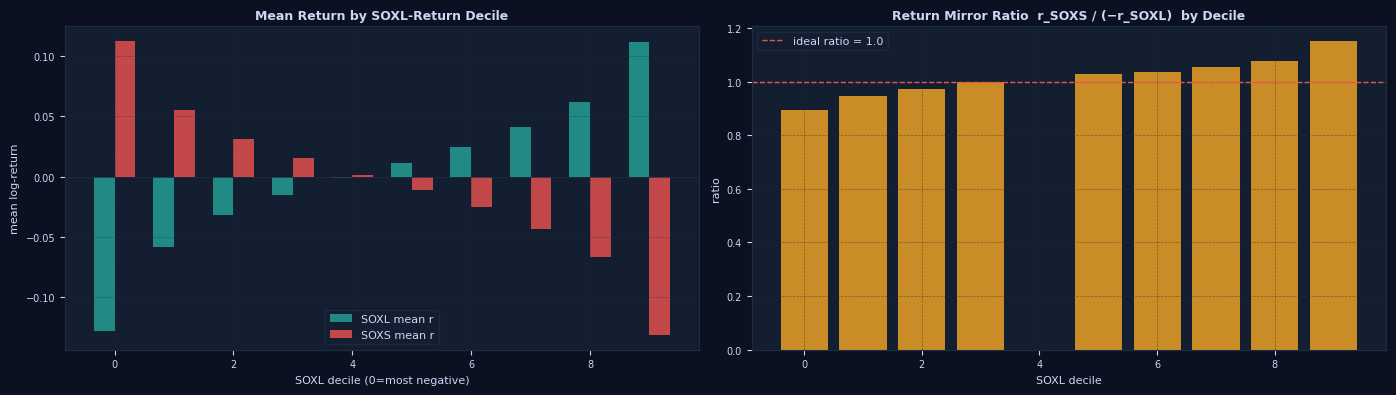

   r_l_mean  r_s_mean  ratio_mean    n
0   -0.1286    0.1129      0.8947  213
1   -0.0582    0.0550      0.9456  212
2   -0.0322    0.0312      0.9716  212
3   -0.0152    0.0152      0.9999  212
4   -0.0013    0.0014         NaN  212
5    0.0109   -0.0113      1.0265  212
6    0.0246   -0.0256      1.0370  212
7    0.0412   -0.0434      1.0529  212
8    0.0623   -0.0671      1.0752  212
9    0.1120   -0.1317      1.1500  212


In [16]:
ret2 = ret.copy()
# observed SOXS return / expected (= -SOXL return)
ret2["ratio_actual"] = ret2["r_s"] / (-ret2["r_l"])  # ideally ≈ 1.0

# bin by SOXL return quartile
ret2["rl_bin"] = pd.qcut(ret2["r_l"], q=10, labels=False)
bin_stats = (
    ret2.groupby("rl_bin")
    .agg(
        r_l_mean=("r_l", "mean"),
        r_s_mean=("r_s", "mean"),
        ratio_mean=("ratio_actual", "mean"),
        n=("r_l", "count"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: mean returns per decile
ax = axes[0]
ax.set_facecolor(BG2)
w = 0.35
xs2 = np.arange(len(bin_stats))
ax.bar(xs2 - w/2, bin_stats["r_l_mean"], width=w, color=GREEN, alpha=0.8, label="SOXL mean r")
ax.bar(xs2 + w/2, bin_stats["r_s_mean"], width=w, color=RED,   alpha=0.8, label="SOXS mean r")
ax.axhline(0, color=GRID, lw=0.5)
style_ax(ax, "Mean Return by SOXL-Return Decile")
ax.set_xlabel("SOXL decile (0=most negative)")
ax.set_ylabel("mean log-return")
ax.legend(fontsize=8, facecolor=BG2, edgecolor=GRID, labelcolor=FG)

# right: ratio (SOXS / -SOXL) per decile — should be ~1
ax2 = axes[1]
ax2.set_facecolor(BG2)
ax2.bar(xs2, bin_stats["ratio_mean"], color=GOLD, alpha=0.8)
ax2.axhline(1.0, color=RED, lw=1.0, ls="--", label="ideal ratio = 1.0")
style_ax(ax2, "Return Mirror Ratio  r_SOXS / (−r_SOXL)  by Decile")
ax2.set_xlabel("SOXL decile")
ax2.set_ylabel("ratio")
ax2.legend(fontsize=8, facecolor=BG2, edgecolor=GRID, labelcolor=FG)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

print(bin_stats[["r_l_mean", "r_s_mean", "ratio_mean", "n"]].to_string(float_format="{:.4f}".format))

## 7. Summary Statistics

In [17]:
lines = [
    "=" * 56,
    "SOXL / SOXS Linear Relationship — Summary",
    "=" * 56,
    f"Period          : {df['date'].iloc[0]}  →  {df['date'].iloc[-1]}",
    f"Trading days    : {len(df)}",
    "",
    "── OLS on daily log-returns ──────────────────────────────",
    f"  alpha (intercept) : {intercept:+.6f}",
    f"  beta              : {slope:.4f}   (ideal = −1.000)",
    f"  R²                : {r2:.4f}",
    f"  Pearson ρ         : {r_val:.4f}",
    f"  Residual σ        : {std_r:.5f}  (log-return)",
    "",
    "── Rolling beta (60d) ────────────────────────────────────",
    f"  mean  : {roll_beta.dropna().mean():.4f}",
    f"  std   : {roll_beta.dropna().std():.4f}",
    f"  min   : {roll_beta.dropna().min():.4f}",
    f"  max   : {roll_beta.dropna().max():.4f}",
    "",
    "── Log-sum trend ─────────────────────────────────────────",
    f"  {m*252:+.4f} nats/year  "
    f"(SOXL outpaces SOXS due to semiconductor bull market)",
    "=" * 56,
]
for l in lines:
    print(l)

SOXL / SOXS Linear Relationship — Summary
Period          : 2018-01-02  →  2026-06-11
Trading days    : 2122

── OLS on daily log-returns ──────────────────────────────
  alpha (intercept) : -0.004783
  beta              : -1.0109   (ideal = −1.000)
  R²                : 0.9604
  Pearson ρ         : -0.9800
  Residual σ        : 0.01384  (log-return)

── Rolling beta (60d) ────────────────────────────────────
  mean  : -1.0076
  std   : 0.0444
  min   : -1.3421
  max   : -0.8550

── Log-sum trend ─────────────────────────────────────────
  -1.2221 nats/year  (SOXL outpaces SOXS due to semiconductor bull market)
